# SWaT Attack Detection

Random Forest, GDN, and T-GCN, evaluated on an attack-disjoint split of the July 2019 SWaT run:
about four hours of plant operation with six attacks near the end. Trains on attacks 1-4 and
preceding normal data, calibrates the detection threshold from the five minutes before attack 6,
tests once on attack 6.

A random row split was tried as a literature-comparable second protocol but dropped. With only
six short attacks in about 15,000 rows, a random split mostly tests memorisation rather than
generalisation, and shrinks an already small training set.

GDN and T-GCN reuse the graph-attention and GCN-propagation mechanisms of Deng and Hooi (2021)
and Zhao et al. (2020), simplified to fit the data here. Graph edges come from pairwise Granger
causality on normal-only training data. Every metric is reported both raw and point-adjusted for
every model.

In [1]:
import itertools
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, average_precision_score, precision_recall_curve,
)
from imblearn.over_sampling import SMOTE
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.multitest import multipletests
import warnings

FILE_PATH_XLSX = "SWaTdatasets/SWaT_dataset_Jul 19 v2.xlsx"
FILE_PATH_CSV = "SWaTdatasets/SWaT_dataset_Jul19_v2.csv"
HEADER_ROW = 1
OUT_DIR = "SWaTdatasets"
TS_COL = "GMT +0"
RANDOM_STATE = 42

ATTACK_WINDOWS = [
    ('2019-07-20 15:08:46', '2019-07-20 15:10:31'),  # FIT401 spoof
    ('2019-07-20 15:15:00', '2019-07-20 15:19:32'),  # LIT301 spoof
    ('2019-07-20 15:26:57', '2019-07-20 15:30:48'),  # P601 OFF->ON
    ('2019-07-20 15:38:50', '2019-07-20 15:46:20'),  # MV201+P101 multi-point
    ('2019-07-20 15:54:00', '2019-07-20 15:56:00'),  # MV501 OPEN->CLOSE
    ('2019-07-20 16:02:56', '2019-07-20 16:16:18'),  # P301 ON->OFF
]

ROLL_WINDOW = 10
WINDOW_GDN = 12           # was 30; shortened for the same reason as WINDOW_TGCN below
WINDOW_TGCN = 12          # short window keeps a window's history and target from both
                          # landing entirely inside the same attack period, which is what
                          # let forecast error quietly "recover" mid-attack at longer windows
STRIDE = 1
CALIB_MINUTES = 5

GRANGER_MAXLAG = 3
GRANGER_ALPHA = 0.05
GRANGER_SUBSAMPLE = 5

EPOCHS = 30
BATCH_SIZE = 128
LR = 1e-3
HIDDEN = 32
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print("Device:", DEVICE)

Device: cpu


## 1. Data and labels

Timestamps are parsed and the first minute of the run is dropped as a settling period. ATTACK_ID is 0 for normal rows and 1 through 6 for the six documented attack windows, converted from Singapore time to UTC. Constant columns are dropped, remaining categorical columns are integer-encoded.

In [2]:
def load_and_label():
    if not os.path.exists(FILE_PATH_CSV):
        raw = pd.read_excel(FILE_PATH_XLSX, header=HEADER_ROW)
        raw.columns = [str(c).strip() for c in raw.columns]
        os.makedirs(os.path.dirname(FILE_PATH_CSV), exist_ok=True)
        raw.to_csv(FILE_PATH_CSV, index=False)
    df = pd.read_csv(FILE_PATH_CSV, low_memory=False)
    df.columns = [str(c).strip() for c in df.columns]

    df[TS_COL] = pd.to_datetime(df[TS_COL], errors='coerce', utc=True)
    df = df.dropna(subset=[TS_COL]).sort_values(TS_COL).reset_index(drop=True)

    plant_start = df[TS_COL].min()
    df = df[df[TS_COL] >= plant_start + pd.Timedelta(minutes=1)].reset_index(drop=True)
    df = df.ffill().bfill()

    df['label'] = 0
    df['ATTACK_ID'] = 0
    for i, (start, end) in enumerate(ATTACK_WINDOWS, start=1):
        start_ts = pd.to_datetime(start).tz_localize('Asia/Singapore').tz_convert('UTC')
        end_ts = pd.to_datetime(end).tz_localize('Asia/Singapore').tz_convert('UTC')
        mask = (df[TS_COL] >= start_ts) & (df[TS_COL] <= end_ts)
        df.loc[mask, 'label'] = 1
        df.loc[mask, 'ATTACK_ID'] = i

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ('label', 'ATTACK_ID')]
    const_cols = df[num_cols].nunique()[lambda s: s <= 1].index.tolist()
    if const_cols:
        df = df.drop(columns=const_cols)

    non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    non_numeric = [c for c in non_numeric if c != TS_COL]
    for c in non_numeric:
        df[c] = df[c].astype('category').cat.codes

    feature_cols = [c for c in df.columns if c not in (TS_COL, 'label', 'ATTACK_ID')]
    print("Shape:", df.shape, "| features:", len(feature_cols))
    print("Attack ratio:", round(df['label'].mean(), 4), f"({df['label'].sum()} of {len(df)} rows)")
    return df, feature_cols


df, FEATURE_COLS = load_and_label()
df.head()

C:\Users\MADHU\AppData\Local\Temp\ipykernel_30656\957057965.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[TS_COL] = pd.to_datetime(df[TS_COL], errors='coerce', utc=True)


Shape: (14936, 80) | features: 77
Attack ratio: 0.1326 (1981 of 14936 rows)


,GMT +0,FIT 101,LIT 101,MV 101,P1_STATE,P101 Status,P102 Status,AIT 201,AIT 202,AIT 203,...,LSH 603,LSL 601,LSL 602,LSL 603,P6 STATE,P601 Status,P602 Status,P603 Status,label,ATTACK_ID
0,2019-07-20 04:31:00.004013+00:00,0,2958,1,1,1,0,230,1066,0,...,0,0,0,0,0,0,0,0,0,0
1,2019-07-20 04:31:01.004013+00:00,0,2956,1,1,1,0,230,1066,1,...,0,0,0,0,0,0,0,0,0,0
2,2019-07-20 04:31:02.002014100+00:00,0,2949,1,1,1,0,230,1066,2,...,0,0,0,0,0,0,0,0,0,0
3,2019-07-20 04:31:03.004013+00:00,0,2946,1,1,1,0,230,1066,3,...,0,0,0,0,0,0,0,0,0,0
4,2019-07-20 04:31:04.004013+00:00,0,2937,1,1,1,0,230,1066,4,...,0,0,0,0,0,0,0,0,0,0


## 2. Split

Train on attacks 1 through 4 plus normal data up to the start of attack 6's calibration slice, excluding attack 5's own five-minute pre-attack slice as well. Test on attack 6 plus its calibration slice. val5 (attack 5 plus its calibration slice) is held out entirely from training and used only for GDN's rule selection in section 9, never to tune against attack 6's labels.

In [3]:
def get_attack_bounds_utc():
    bounds = []
    for start, end in ATTACK_WINDOWS:
        s = pd.to_datetime(start).tz_localize('Asia/Singapore').tz_convert('UTC')
        e = pd.to_datetime(end).tz_localize('Asia/Singapore').tz_convert('UTC')
        bounds.append((s, e))
    return bounds


attack_bounds = get_attack_bounds_utc()
ATTACK5_START, ATTACK5_END = attack_bounds[4]
ATTACK6_START, ATTACK6_END = attack_bounds[5]
CALIB5_START = ATTACK5_START - pd.Timedelta(minutes=CALIB_MINUTES)
CALIB_START = ATTACK6_START - pd.Timedelta(minutes=CALIB_MINUTES)

row_idx = np.arange(len(df))
y_all = df['label'].values
attack_id_all = df['ATTACK_ID'].values

ts_vals = df[TS_COL].values
in_calib5_window = (ts_vals >= np.datetime64(CALIB5_START)) & (ts_vals < np.datetime64(ATTACK5_START))

train_idx = row_idx[(attack_id_all <= 4) & (ts_vals < np.datetime64(CALIB_START)) & (~in_calib5_window)]
test_idx = row_idx[(ts_vals >= np.datetime64(CALIB_START)) & (ts_vals <= np.datetime64(ATTACK6_END))]
val5_idx = row_idx[(ts_vals >= np.datetime64(CALIB5_START)) & (ts_vals <= np.datetime64(ATTACK5_END))]

print(f"train: {len(train_idx)} rows ({y_all[train_idx].sum()} attack rows, attacks 1-4)")
print(f"test:  {len(test_idx)} rows ({y_all[test_idx].sum()} attack rows, attack 6 plus a "
      f"{CALIB_MINUTES}-minute pre-attack calibration slice)")
print(f"val5:  {len(val5_idx)} rows ({y_all[val5_idx].sum()} attack rows, attack 5 plus its own "
      f"{CALIB_MINUTES}-minute pre-attack slice), excluded from training and used only to select "
      f"a calibration rule, never to tune against attack 6's labels")
print("Both attack 5's and attack 6's pre-attack calibration slices are excluded from training, "
      "so neither is ever partially memorised before being used for calibration.")

train: 11992 rows (1059 attack rows, attacks 1-4)
test:  1102 rows (802 attack rows, attack 6 plus a 5-minute pre-attack calibration slice)
val5:  420 rows (120 attack rows, attack 5 plus its own 5-minute pre-attack slice), excluded from training and used only to select a calibration rule, never to tune against attack 6's labels
Both attack 5's and attack 6's pre-attack calibration slices are excluded from training, so neither is ever partially memorised before being used for calibration.


C:\Users\MADHU\AppData\Local\Temp\ipykernel_30656\2559818620.py:21: UserWarning: no explicit representation of timezones available for np.datetime64
  in_calib5_window = (ts_vals >= np.datetime64(CALIB5_START)) & (ts_vals < np.datetime64(ATTACK5_START))
C:\Users\MADHU\AppData\Local\Temp\ipykernel_30656\2559818620.py:23: UserWarning: no explicit representation of timezones available for np.datetime64
  train_idx = row_idx[(attack_id_all <= 4) & (ts_vals < np.datetime64(CALIB_START)) & (~in_calib5_window)]
C:\Users\MADHU\AppData\Local\Temp\ipykernel_30656\2559818620.py:24: UserWarning: no explicit representation of timezones available for np.datetime64
  test_idx = row_idx[(ts_vals >= np.datetime64(CALIB_START)) & (ts_vals <= np.datetime64(ATTACK6_END))]
C:\Users\MADHU\AppData\Local\Temp\ipykernel_30656\2559818620.py:25: UserWarning: no explicit representation of timezones available for np.datetime64
  val5_idx = row_idx[(ts_vals >= np.datetime64(CALIB5_START)) & (ts_vals <= np.datetime6

## 3. Attack overlap

Rows in train versus test versus val5 for each attack. Attacks 1 through 4 are train-only, attack 5 is val5-only, attack 6 is test-only.

In [4]:
def attack_overlap_table(train_idx, eval_idx, val_idx):
    train_set, eval_set, val_set = set(train_idx.tolist()), set(eval_idx.tolist()), set(val_idx.tolist())
    print(f"{'Attack ID':>10} | {'Rows in train':>15} | {'Rows in test':>15} | {'Rows in val5':>15} | {'Overlap?':>10}")
    for attack_id in range(1, 7):
        attack_rows = set(row_idx[attack_id_all == attack_id].tolist())
        in_train = len(attack_rows & train_set)
        in_eval = len(attack_rows & eval_set)
        in_val = len(attack_rows & val_set)
        overlap = "YES" if (in_train > 0 and (in_eval > 0 or in_val > 0)) else "no"
        print(f"{attack_id:>10} | {in_train:>15} | {in_eval:>15} | {in_val:>15} | {overlap:>10}")


attack_overlap_table(train_idx, test_idx, val5_idx)

 Attack ID |   Rows in train |    Rows in test |    Rows in val5 |   Overlap?
         1 |             105 |               0 |               0 |         no
         2 |             272 |               0 |               0 |         no
         3 |             232 |               0 |               0 |         no
         4 |             450 |               0 |               0 |         no
         5 |               0 |               0 |             120 |         no
         6 |               0 |             802 |               0 |         no


## 4. Evaluation utilities

Point adjustment credits a whole attack segment as detected if any point inside it is flagged, standard practice for this kind of evaluation but only meaningful when the test set has more than one independent attack segment. Every model is reported both ways, raw and point-adjusted. threshold_from_rule and CALIBRATION_RULES support both a plain mean-plus-3-std threshold and a menu of percentile-based ones selected via attack 5, used only where noted in each model's section below.

In [5]:
def point_adjust(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int).copy()
    anomaly_state = False
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1 and not anomaly_state:
            anomaly_state = True
            for j in range(i, 0, -1):
                if y_true[j] == 0:
                    break
                if y_pred[j] == 0:
                    y_pred[j] = 1
        elif y_true[i] == 0:
            anomaly_state = False
        if anomaly_state:
            y_pred[i] = 1
    return y_pred


def metrics_at_threshold(y_true, scores, thr, use_point_adjust=True):
    pred = (np.asarray(scores) >= thr).astype(int)
    pred_eval = point_adjust(y_true, pred) if use_point_adjust else pred
    return {
        "accuracy": accuracy_score(y_true, pred_eval),
        "f1": f1_score(y_true, pred_eval, zero_division=0),
        "precision": precision_score(y_true, pred_eval, zero_division=0),
        "recall": recall_score(y_true, pred_eval, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores) if len(set(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, scores) if len(set(y_true)) > 1 else np.nan,
    }


def full_report(name, y_true, scores, thr):
    """Reports both raw and point-adjusted metrics for every model, not
    just T-GCN, so nothing is hidden behind point-adjustment without the
    raw numbers sitting right next to it."""
    pa = metrics_at_threshold(y_true, scores, thr, use_point_adjust=True)
    raw = metrics_at_threshold(y_true, scores, thr, use_point_adjust=False)
    print(f"{name}, point-adjusted:", {k: round(v, 3) for k, v in pa.items()})
    print(f"{name}, raw:           ", {k: round(v, 3) for k, v in raw.items()})
    if raw["roc_auc"] < 0.55:
        print(f"  Note: {name}'s ROC-AUC is at or below chance level. Point-adjusted F1 on a single "
              f"contiguous test segment can look inflated from one lucky flagged window; raw metrics "
              f"and ROC-AUC are the trustworthy numbers here, not the point-adjusted F1.")
    return pa, raw


def threshold_from_rule(rule, calib_scores, all_scores):
    """A named threshold rule applied to a calibration slice's scores,
    capped at the 99th percentile of all_scores so a noisy calibration
    slice can never push the threshold past what those scores reach."""
    if rule == "mean3std":
        thr = calib_scores.mean() + 3 * calib_scores.std()
    else:
        pct = int(rule.replace("pct", ""))
        thr = np.percentile(calib_scores, pct)
    return min(thr, np.percentile(all_scores, 99)) if np.isfinite(thr) else np.percentile(all_scores, 99)


CALIBRATION_RULES = ["mean3std", "pct75", "pct90", "pct95"]


def select_rule_via_attack5(val5_scores, val5_calib_scores, val5_labels, min_rows=10):
    """Tries every candidate rule against attack 5 only, scored on raw
    (non-point-adjusted) F1, and returns whichever rule wins there. Never
    looks at attack 6. The same rule is then reapplied fresh to attack 6's
    own calibration slice -- the numeric threshold is not reused across
    attacks, only the choice of rule, since scores were found not to
    transfer between attacks but the shape of a good rule might."""
    if len(val5_calib_scores) < min_rows:
        return "mean3std", None
    best_rule, best_f1 = None, -1
    for rule in CALIBRATION_RULES:
        thr = threshold_from_rule(rule, val5_calib_scores, val5_scores)
        pred = (np.asarray(val5_scores) >= thr).astype(int)
        f1 = f1_score(val5_labels, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_rule = f1, rule
    return best_rule, best_f1


def calibrate_threshold_rowwise(scores, ts_series, rule):
    calib_mask = (ts_series.values >= np.datetime64(CALIB_START)) & (ts_series.values < np.datetime64(ATTACK6_START))
    calib_scores = np.asarray(scores)[calib_mask]
    if calib_mask.sum() < 10:
        return np.percentile(scores, 95)
    return threshold_from_rule(rule, calib_scores, scores)


def calibrate_threshold_windowed(scores, ts_series, window, rule):
    n = len(scores)
    if n == 0:
        return 0.0
    aligned_ts = pd.to_datetime(ts_series.values[window - 1: window - 1 + n], utc=True)
    calib_mask = np.asarray((aligned_ts >= CALIB_START) & (aligned_ts < ATTACK6_START))
    calib_scores = np.asarray(scores)[calib_mask]
    if calib_mask.sum() < 10:
        return np.percentile(scores, 95)
    return threshold_from_rule(rule, calib_scores, scores)

## 5. Random Forest

Rolling mean, standard deviation, min, max, and first difference over a ten-row window, computed once on the full chronologically-ordered data. Class-weighted rather than SMOTE-balanced. Threshold is mean plus three standard deviations of the pre-attack-6 calibration slice.

In [6]:
def add_rolling_features(data, cols, window):
    roll = data[cols].rolling(window, min_periods=1)
    feats = pd.concat([
        roll.mean().add_suffix('_mean'),
        roll.std().add_suffix('_std').fillna(0),
        roll.min().add_suffix('_min'),
        roll.max().add_suffix('_max'),
        data[cols].diff().fillna(0).add_suffix('_delta'),
    ], axis=1)
    return feats


roll_feats_all = add_rolling_features(df, FEATURE_COLS, ROLL_WINDOW)
X_all = pd.concat([df[FEATURE_COLS], roll_feats_all], axis=1).replace([np.inf, -np.inf], 0).fillna(0).values
print("Feature matrix shape:", X_all.shape)

scaler_rf = StandardScaler().fit(X_all[train_idx])
X_train_rf = scaler_rf.transform(X_all[train_idx])
X_test_rf = scaler_rf.transform(X_all[test_idx])
y_train_rf, y_test_rf = y_all[train_idx], y_all[test_idx]

rf = RandomForestClassifier(
    n_estimators=500, min_samples_leaf=1, max_features="sqrt",
    class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_rf, y_train_rf)
test_probs_rf = rf.predict_proba(X_test_rf)[:, 1]

X_val5_rf = scaler_rf.transform(X_all[val5_idx])
y_val5_rf = y_all[val5_idx]
val5_probs_rf = rf.predict_proba(X_val5_rf)[:, 1]

ts_val5_rf = df.iloc[val5_idx][TS_COL]
calib5_mask_rf = (ts_val5_rf.values >= np.datetime64(CALIB5_START)) & (ts_val5_rf.values < np.datetime64(ATTACK5_START))
calib5_scores_rf = val5_probs_rf[calib5_mask_rf]

rf_rule, rf_rule_f1 = select_rule_via_attack5(val5_probs_rf, calib5_scores_rf, y_val5_rf)
print(f"Random Forest calibration rule selected via attack 5: {rf_rule} (attack 5 raw F1={rf_rule_f1})")

ts_test = df.iloc[test_idx][TS_COL]
rf_threshold = calibrate_threshold_rowwise(test_probs_rf, ts_test, rf_rule)
rf_results_pa, rf_results_raw = full_report("Random Forest", y_test_rf, test_probs_rf, rf_threshold)

Feature matrix shape: (14936, 462)
Random Forest calibration rule selected via attack 5: pct75 (attack 5 raw F1=0.11214953271028037)
Random Forest, point-adjusted: {'accuracy': 0.931, 'f1': 0.955, 'precision': 0.913, 'recall': 1.0, 'roc_auc': 0.58, 'pr_auc': 0.806}
Random Forest, raw:            {'accuracy': 0.435, 'f1': 0.45, 'precision': 0.77, 'recall': 0.318, 'roc_auc': 0.58, 'pr_auc': 0.806}


C:\Users\MADHU\AppData\Local\Temp\ipykernel_30656\2907353130.py:34: UserWarning: no explicit representation of timezones available for np.datetime64
  calib5_mask_rf = (ts_val5_rf.values >= np.datetime64(CALIB5_START)) & (ts_val5_rf.values < np.datetime64(ATTACK5_START))
C:\Users\MADHU\AppData\Local\Temp\ipykernel_30656\145187209.py:83: UserWarning: no explicit representation of timezones available for np.datetime64
  calib_mask = (ts_series.values >= np.datetime64(CALIB_START)) & (ts_series.values < np.datetime64(ATTACK6_START))


## 6. Sensor graph

Directed edges from pairwise Granger causality tests on normal-only training rows. adj[cause, effect] = 1 if cause's past significantly improves prediction of effect at lag 3, after Benjamini-Hochberg FDR correction across all pairs tested.

In [7]:
def build_granger_adjacency(normal_scaled, maxlag=GRANGER_MAXLAG, alpha=GRANGER_ALPHA, subsample=GRANGER_SUBSAMPLE,
                             verbose=True):
    n = normal_scaled.shape[1]
    data = normal_scaled[::subsample] if subsample > 1 else normal_scaled

    pairs, pvals = [], []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for cause, effect in itertools.permutations(range(n), 2):
            x = data[:, [effect, cause]]
            try:
                res = grangercausalitytests(x, maxlag=[maxlag])
                p = res[maxlag][0]['ssr_ftest'][1]
            except Exception:
                p = 1.0
            pairs.append((cause, effect))
            pvals.append(p)

    reject, _, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
    adj = np.zeros((n, n), dtype=np.float32)
    for (cause, effect), rej in zip(pairs, reject):
        if rej:
            adj[cause, effect] = 1.0
    np.fill_diagonal(adj, 1.0)

    n_edges = int(adj.sum()) - n
    if verbose:
        print(f"Granger graph, lag={maxlag}: {n_edges} directed edges out of {n * (n - 1)} ordered pairs "
              f"tested (FDR alpha={alpha})")
    return adj


sensor_cols = [c for c in FEATURE_COLS if df[c].nunique() > 1]
n_nodes = len(sensor_cols)

normal_train = df.iloc[train_idx]
normal_train = normal_train[normal_train['label'] == 0]
scaler_g = StandardScaler().fit(normal_train[sensor_cols])
normal_scaled_g = scaler_g.transform(normal_train[sensor_cols])

adj = build_granger_adjacency(normal_scaled_g)
edge_index = torch.tensor(np.array(np.nonzero(adj)), dtype=torch.long).to(DEVICE)

adj_t = adj.T
deg = adj_t.sum(axis=1, keepdims=True)
deg[deg == 0] = 1.0
adj_norm = torch.tensor(adj_t / deg, dtype=torch.float32).to(DEVICE)

Granger graph, lag=3: 302 directed edges out of 1892 ordered pairs tested (FDR alpha=0.05)


## 7. Granger lag sensitivity

The graph above uses lag 3. Rebuilt at lag 1 and lag 5 to check how much the resulting edge set actually depends on that choice.

In [8]:
lag_edge_counts = {}
lag_adjacencies = {}
for lag in (1, 3, 5):
    adj_lag = build_granger_adjacency(normal_scaled_g, maxlag=lag, verbose=True)
    lag_adjacencies[lag] = adj_lag
    lag_edge_counts[lag] = int(adj_lag.sum()) - n_nodes

print("\nEdge count by lag:", lag_edge_counts)

overlap_1_3 = (lag_adjacencies[1] * lag_adjacencies[3]).sum() - n_nodes
overlap_3_5 = (lag_adjacencies[3] * lag_adjacencies[5]).sum() - n_nodes
print(f"Edges shared between lag=1 and lag=3: {int(overlap_1_3)} / {lag_edge_counts[3]}")
print(f"Edges shared between lag=3 and lag=5: {int(overlap_3_5)} / {lag_edge_counts[3]}")
print("A large fraction of shared edges across lags means the choice of lag is not doing much of the "
      "work; a small fraction means results may be sensitive to it and the choice needs justifying "
      "on process-dynamics grounds, not just convention.")

Granger graph, lag=1: 396 directed edges out of 1892 ordered pairs tested (FDR alpha=0.05)
Granger graph, lag=3: 302 directed edges out of 1892 ordered pairs tested (FDR alpha=0.05)
Granger graph, lag=5: 278 directed edges out of 1892 ordered pairs tested (FDR alpha=0.05)

Edge count by lag: {1: 396, 3: 302, 5: 278}
Edges shared between lag=1 and lag=3: 252 / 302
Edges shared between lag=3 and lag=5: 240 / 302
A large fraction of shared edges across lags means the choice of lag is not doing much of the work; a small fraction means results may be sensitive to it and the choice needs justifying on process-dynamics grounds, not just convention.


## 8. Forecaster windowing

GDN and T-GCN train on normal windows only, drawn from the training partition. Test windows surround attack 6, val5 windows surround attack 5 and are used only by GDN's rule selection.

In [9]:
def make_windows(data, labels, window, stride):
    Xs, ys = [], []
    for i in range(0, len(data) - window, stride):
        Xs.append(data[i:i + window])
        ys.append(int(labels[i + window - 1]))
    if not Xs:
        return np.empty((0, window, data.shape[1])), np.empty((0,))
    return np.array(Xs), np.array(ys)


df_train = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)
df_val5 = df.iloc[val5_idx].reset_index(drop=True)

train_scaled_g = scaler_g.transform(df_train[sensor_cols])
test_scaled_g = scaler_g.transform(df_test[sensor_cols])
val5_scaled_g = scaler_g.transform(df_val5[sensor_cols])
normal_mask_train = df_train['label'].values == 0


def build_forecast_windows(window):
    Xw_train, _ = make_windows(train_scaled_g[normal_mask_train], df_train['label'].values[normal_mask_train],
                                window, STRIDE)
    Xw_test, yw_test = make_windows(test_scaled_g, df_test['label'].values, window, STRIDE)
    Xw_val5, yw_val5 = make_windows(val5_scaled_g, df_val5['label'].values, window, STRIDE)
    return Xw_train, Xw_test, yw_test, Xw_val5, yw_val5


def select_forecaster_rule(model, edge_or_adj, err_mean, err_std, Xw_val5, yw_val5, window):
    if len(Xw_val5) == 0:
        return "mean3std", None
    val5_scores, val5_labels = score_forecaster(model, edge_or_adj, Xw_val5, yw_val5, err_mean, err_std)
    aligned_ts = pd.to_datetime(df_val5[TS_COL].values[window - 1: window - 1 + len(val5_scores)], utc=True)
    calib_mask = np.asarray((aligned_ts >= CALIB5_START) & (aligned_ts < ATTACK5_START))
    calib_scores = val5_scores[calib_mask]
    return select_rule_via_attack5(val5_scores, calib_scores, val5_labels)

## 9. GDN

Graph attention per timestep, with each node's history encoded by its own GRU before attention is applied. Trained on normal windows only; anomaly score is the per-sensor forecast error, z-scored against each sensor's own normal-operation error distribution and maxed across sensors. Unlike the other three models, GDN's threshold rule is selected from a menu of candidates by whichever wins on attack 5, since the plain mean-plus-3-std rule left a large gap between GDN's ROC-AUC and its raw detection rate that the other models did not show.

In [10]:
class GDN(nn.Module):
    def __init__(self, n_nodes, hidden):
        super().__init__()
        self.n_nodes = n_nodes
        self.hidden = hidden
        self.node_embed = nn.Parameter(torch.randn(n_nodes, hidden))
        self.hist_enc = nn.GRU(1, hidden, batch_first=True)
        self.attn = nn.Linear(2 * hidden, 1)
        self.out = nn.Linear(hidden, 1)

    def forward(self, x, edge_index):
        history = x[:, :-1, :]
        target = x[:, -1, :]
        b, t, n = history.shape

        hist_in = history.permute(0, 2, 1).reshape(b * n, t, 1)
        _, hn = self.hist_enc(hist_in)
        h = hn.squeeze(0).reshape(b, n, self.hidden)

        src, dst = edge_index
        e_src = self.node_embed[src].unsqueeze(0).expand(b, -1, -1)
        e_dst = self.node_embed[dst].unsqueeze(0).expand(b, -1, -1)
        alpha = torch.softmax(self.attn(torch.cat([e_src, e_dst], dim=-1)).squeeze(-1), dim=-1)

        agg = torch.zeros(b, n, self.hidden, device=x.device)
        agg.index_add_(1, dst, alpha.unsqueeze(-1) * h[:, src, :])

        pred = self.out(agg).squeeze(-1)
        per_node_err = (pred - target).pow(2)
        score = per_node_err.mean(dim=1)
        return score, per_node_err


def train_forecaster(model, edge_or_adj, Xw_train, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE):
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(Xw_train, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            score, _ = model(xb, edge_or_adj)
            loss = score.mean()
            loss.backward()
            opt.step()
    return model, loader


def score_forecaster(model, edge_or_adj, Xw, yw, err_mean, err_std, batch_size=BATCH_SIZE):
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(Xw, dtype=torch.float32), torch.tensor(yw, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False)
    model.eval()
    scores, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            _, per_node_err = model(xb, edge_or_adj)
            z = (per_node_err.cpu().numpy() - err_mean) / err_std
            scores.append(z.max(axis=1))
            labels.append(yb.numpy())
    return np.concatenate(scores), np.concatenate(labels)


def fit_error_stats(model, edge_or_adj, loader):
    model.eval()
    errs = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            _, per_node_err = model(xb, edge_or_adj)
            errs.append(per_node_err.cpu().numpy())
    errs = np.concatenate(errs)
    return errs.mean(axis=0), errs.std(axis=0) + 1e-6


torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Xw_train_gdn, Xw_test_gdn, yw_test_gdn, Xw_val5_gdn, yw_val5_gdn = build_forecast_windows(WINDOW_GDN)
gdn = GDN(n_nodes, HIDDEN).to(DEVICE)
gdn, gdn_train_loader = train_forecaster(gdn, edge_index, Xw_train_gdn)
gdn_err_mean, gdn_err_std = fit_error_stats(gdn, edge_index, gdn_train_loader)

gdn_rule, gdn_rule_f1 = select_forecaster_rule(gdn, edge_index, gdn_err_mean, gdn_err_std, Xw_val5_gdn, yw_val5_gdn, WINDOW_GDN)
print(f"GDN calibration rule selected via attack 5: {gdn_rule} (attack 5 raw F1={gdn_rule_f1})")

gdn_test_scores, gdn_test_labels = score_forecaster(gdn, edge_index, Xw_test_gdn, yw_test_gdn, gdn_err_mean, gdn_err_std)
gdn_threshold = calibrate_threshold_windowed(gdn_test_scores, df_test[TS_COL], WINDOW_GDN, gdn_rule)
gdn_results_pa, gdn_results_raw = full_report("GDN", gdn_test_labels, gdn_test_scores, gdn_threshold)

GDN calibration rule selected via attack 5: pct75 (attack 5 raw F1=0.41025641025641024)
GDN, point-adjusted: {'accuracy': 0.933, 'f1': 0.956, 'precision': 0.916, 'recall': 1.0, 'roc_auc': 0.684, 'pr_auc': 0.858}
GDN, raw:            {'accuracy': 0.738, 'f1': 0.804, 'precision': 0.89, 'recall': 0.734, 'roc_auc': 0.684, 'pr_auc': 0.858}


## 10. T-GCN forecaster

Fixed graph convolution per timestep, propagated through a GRU, same training and scoring scheme as GDN, and no more supervised than GDN is: trained on normal windows only, never touches attack labels. Threshold is mean plus three standard deviations of the pre-attack-6 calibration slice.

In [11]:
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)

    def forward(self, x, adj_norm):
        agg = torch.einsum('ij,bjd->bid', adj_norm, x)
        return torch.relu(self.lin(agg))


class TGCN(nn.Module):
    def __init__(self, n_nodes, hidden):
        super().__init__()
        self.gcn = GCNLayer(1, hidden)
        self.gru = nn.GRU(hidden * n_nodes, hidden, batch_first=True)
        self.out = nn.Linear(hidden, n_nodes)
        self.n_nodes = n_nodes

    def forward(self, x, adj_norm):
        history = x[:, :-1, :]
        target = x[:, -1, :]
        b, t, n = history.shape
        gcn_out = []
        for step in range(t):
            xt = history[:, step, :].unsqueeze(-1)
            h = self.gcn(xt, adj_norm)
            gcn_out.append(h.reshape(b, -1))
        seq = torch.stack(gcn_out, dim=1)
        _, hn = self.gru(seq)
        pred = self.out(hn.squeeze(0))
        per_node_err = (pred - target).pow(2)
        score = per_node_err.mean(dim=1)
        return score, per_node_err


torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Xw_train_tgcn, Xw_test_tgcn, yw_test_tgcn, Xw_val5_tgcn, yw_val5_tgcn = build_forecast_windows(WINDOW_TGCN)
tgcn = TGCN(n_nodes, HIDDEN).to(DEVICE)
tgcn, tgcn_train_loader = train_forecaster(tgcn, adj_norm, Xw_train_tgcn)
tgcn_err_mean, tgcn_err_std = fit_error_stats(tgcn, adj_norm, tgcn_train_loader)

tgcn_test_scores, tgcn_test_labels = score_forecaster(tgcn, adj_norm, Xw_test_tgcn, yw_test_tgcn, tgcn_err_mean, tgcn_err_std)

tgcn_rule, tgcn_rule_f1 = select_forecaster_rule(tgcn, adj_norm, tgcn_err_mean, tgcn_err_std, Xw_val5_tgcn, yw_val5_tgcn, WINDOW_TGCN)
print(f"T-GCN forecaster calibration rule selected via attack 5: {tgcn_rule} (attack 5 raw F1={tgcn_rule_f1})")

tgcn_threshold = calibrate_threshold_windowed(tgcn_test_scores, df_test[TS_COL], WINDOW_TGCN, tgcn_rule)
tgcn_results_pa, tgcn_results_raw = full_report("T-GCN forecaster", tgcn_test_labels, tgcn_test_scores, tgcn_threshold)

T-GCN forecaster calibration rule selected via attack 5: pct75 (attack 5 raw F1=0.4066390041493776)
T-GCN forecaster, point-adjusted: {'accuracy': 0.933, 'f1': 0.956, 'precision': 0.916, 'recall': 1.0, 'roc_auc': 0.842, 'pr_auc': 0.906}
T-GCN forecaster, raw:            {'accuracy': 0.743, 'f1': 0.809, 'precision': 0.891, 'recall': 0.742, 'roc_auc': 0.842, 'pr_auc': 0.906}


## 11. T-GCN classifier

Same graph-conv-plus-GRU backbone, retrained as a binary classifier on the full labeled training partition with SMOTE applied to the windowed representation. This is the only supervised model of the three graph-based ones. Threshold is mean plus three standard deviations of the pre-attack-6 calibration slice.

In [12]:
class TGCNClassifier(nn.Module):
    def __init__(self, n_nodes, hidden):
        super().__init__()
        self.gcn = GCNLayer(1, hidden)
        self.gru = nn.GRU(hidden * n_nodes, hidden, batch_first=True)
        self.classifier = nn.Linear(hidden, 1)
        self.n_nodes = n_nodes

    def forward(self, x, adj_norm):
        b, t, n = x.shape
        gcn_out = []
        for step in range(t):
            xt = x[:, step, :].unsqueeze(-1)
            h = self.gcn(xt, adj_norm)
            gcn_out.append(h.reshape(b, -1))
        seq = torch.stack(gcn_out, dim=1)
        _, hn = self.gru(seq)
        return self.classifier(hn.squeeze(0)).squeeze(-1)


Xw_train_full, yw_train_full = make_windows(train_scaled_g, df_train['label'].values, WINDOW_TGCN, STRIDE)
n_train_windows, win_len, _ = Xw_train_full.shape
X_flat = Xw_train_full.reshape(n_train_windows, -1)

minority_n = int(yw_train_full.sum())
k_neighbors = max(1, min(5, minority_n - 1))
smote = SMOTE(sampling_strategy='auto', k_neighbors=k_neighbors, random_state=RANDOM_STATE)
X_flat_bal, y_train_bal = smote.fit_resample(X_flat, yw_train_full)
X_train_bal = X_flat_bal.reshape(-1, win_len, n_nodes)
print(f"SMOTE: train {n_train_windows} -> {len(y_train_bal)} windows (k_neighbors={k_neighbors})")

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

tgcn_clf = TGCNClassifier(n_nodes, HIDDEN).to(DEVICE)
opt = torch.optim.Adam(tgcn_clf.parameters(), lr=LR)
loss_fn = nn.BCEWithLogitsLoss()
clf_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_train_bal, dtype=torch.float32), torch.tensor(y_train_bal, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=True)

for epoch in range(EPOCHS):
    tgcn_clf.train()
    for xb, yb in clf_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = loss_fn(tgcn_clf(xb, adj_norm), yb)
        loss.backward()
        opt.step()


def score_classifier(model, Xw, yw, batch_size=BATCH_SIZE):
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(Xw, dtype=torch.float32), torch.tensor(yw, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False)
    model.eval()
    scores, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            prob = torch.sigmoid(model(xb, adj_norm))
            scores.append(prob.cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(scores), np.concatenate(labels)


Xw_test_clf, yw_test_clf = make_windows(test_scaled_g, df_test['label'].values, WINDOW_TGCN, STRIDE)
tgcn_clf_test_scores, tgcn_clf_test_labels = score_classifier(tgcn_clf, Xw_test_clf, yw_test_clf)

tgcn_clf_val5_scores, tgcn_clf_val5_labels = score_classifier(tgcn_clf, Xw_val5_tgcn, yw_val5_tgcn)
aligned_ts_val5_clf = pd.to_datetime(
    df_val5[TS_COL].values[WINDOW_TGCN - 1: WINDOW_TGCN - 1 + len(tgcn_clf_val5_scores)], utc=True
)
calib5_mask_clf = np.asarray((aligned_ts_val5_clf >= CALIB5_START) & (aligned_ts_val5_clf < ATTACK5_START))
calib5_scores_clf = tgcn_clf_val5_scores[calib5_mask_clf]

tgcn_clf_rule, tgcn_clf_rule_f1 = select_rule_via_attack5(tgcn_clf_val5_scores, calib5_scores_clf, tgcn_clf_val5_labels)
print(f"T-GCN classifier calibration rule selected via attack 5: {tgcn_clf_rule} (attack 5 raw F1={tgcn_clf_rule_f1})")

tgcn_clf_threshold = calibrate_threshold_windowed(tgcn_clf_test_scores, df_test[TS_COL], WINDOW_TGCN, tgcn_clf_rule)
tgcn_clf_results_pa, tgcn_clf_results_raw = full_report("T-GCN classifier", tgcn_clf_test_labels, tgcn_clf_test_scores, tgcn_clf_threshold)

SMOTE: train 11980 -> 21842 windows (k_neighbors=5)
T-GCN classifier calibration rule selected via attack 5: pct75 (attack 5 raw F1=0.3157894736842105)
T-GCN classifier, point-adjusted: {'accuracy': 0.933, 'f1': 0.956, 'precision': 0.916, 'recall': 1.0, 'roc_auc': 0.61, 'pr_auc': 0.766}
T-GCN classifier, raw:            {'accuracy': 0.283, 'f1': 0.192, 'precision': 0.56, 'recall': 0.116, 'roc_auc': 0.61, 'pr_auc': 0.766}


## 12. Summary

Accuracy, F1, precision, recall, ROC-AUC, and PR-AUC for every model, reported both raw and point-adjusted.

In [13]:
def tag_rows(model_name, pa, raw):
    return [
        {"Model": model_name, "Metric set": "point-adjusted", **pa},
        {"Model": model_name, "Metric set": "raw", **raw},
    ]


summary_rows = (
    tag_rows("Random Forest", rf_results_pa, rf_results_raw)
    + tag_rows("GDN", gdn_results_pa, gdn_results_raw)
    + tag_rows("T-GCN (forecaster)", tgcn_results_pa, tgcn_results_raw)
    + tag_rows("T-GCN (classifier)", tgcn_clf_results_pa, tgcn_clf_results_raw)
)
summary_df = pd.DataFrame(summary_rows).set_index(["Model", "Metric set"])
summary_df = summary_df[["accuracy", "f1", "precision", "recall", "roc_auc", "pr_auc"]].round(3)
summary_df.to_csv(os.path.join(OUT_DIR, "model_comparison.csv"))
summary_df

accuracy     f1  precision  recall  \
Model              Metric set                                           
Random Forest      point-adjusted     0.931  0.955      0.913   1.000   
                   raw                0.435  0.450      0.770   0.318   
GDN                point-adjusted     0.933  0.956      0.916   1.000   
                   raw                0.738  0.804      0.890   0.734   
T-GCN (forecaster) point-adjusted     0.933  0.956      0.916   1.000   
                   raw                0.743  0.809      0.891   0.742   
T-GCN (classifier) point-adjusted     0.933  0.956      0.916   1.000   
                   raw                0.283  0.192      0.560   0.116   

                                   roc_auc  pr_auc  
Model              Metric set                       
Random Forest      point-adjusted    0.580   0.806  
                   raw               0.580   0.806  
GDN                point-adjusted    0.684   0.858  
                   raw               0.684   0.858  
T-GCN (forecaster) point-adjusted    0.842   0.906  
                   raw               0.842   0.906  
T-GCN (classifier) point-adjusted    0.610   0.766  
                   raw               0.610   0.766

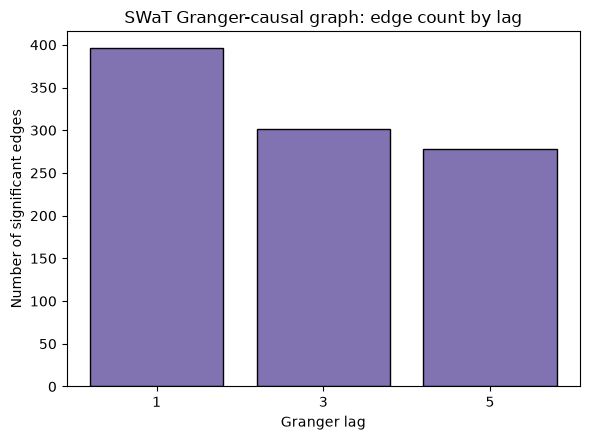

In [14]:
import matplotlib.pyplot as plt

lags = [1, 3, 5]
edge_counts = [lag_edge_counts[l] for l in lags]  # <-- confirm this dict name matches your notebook

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar([str(l) for l in lags], edge_counts, color="#8172B2", edgecolor="black")
ax.set_xlabel("Granger lag")
ax.set_ylabel("Number of significant edges")
ax.set_title("SWaT Granger-causal graph: edge count by lag")
plt.tight_layout()
plt.savefig("fig4_5_swat_granger_lag_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

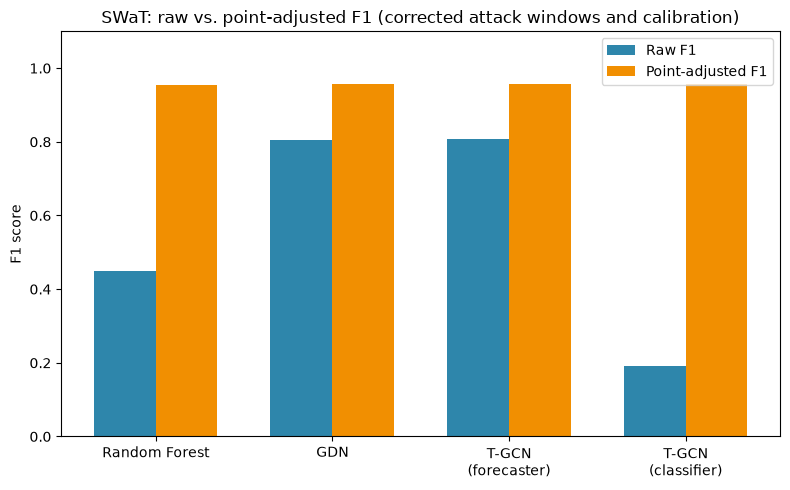

In [15]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Random Forest", "GDN", "T-GCN\n(forecaster)", "T-GCN\n(classifier)"]
raw_f1 = [0.450, 0.804, 0.809, 0.192]
pa_f1  = [0.955, 0.956, 0.956, 0.956]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, raw_f1, width, label="Raw F1", color="#2E86AB")
ax.bar(x + width/2, pa_f1, width, label="Point-adjusted F1", color="#F18F01")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_title("SWaT: raw vs. point-adjusted F1 (corrected attack windows and calibration)")
plt.tight_layout()
plt.savefig("fig4_6_swat_raw_vs_pointadjusted.png", dpi=150, bbox_inches="tight")
plt.show()